In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
import joblib

pd.set_option('display.max_columns', None)
print("Setup complete.")

Setup complete.


In [43]:
product_catalog = pd.read_csv('./resources/ReturnPredictionData/product_catalog.csv')
product_catalog.head()

,product_id,sku,product_name,description,category,sub_category,brand,price,stock_status,avg_rating
0,P1001,SKU-ELE-1001,Voltix Signature Headphone,The Voltix Signature Headphone delivers reliab...,Electronics,Headphones,Voltix,13230.33,In Stock,4.0
1,P1002,SKU-ELE-1002,Pulseon Premium Headphone,The Pulseon Premium Headphone delivers reliabl...,Electronics,Headphones,Pulseon,10762.92,In Stock,3.0
2,P1003,SKU-ELE-1003,Nexbyte Active Headphone,The Nexbyte Active Headphone delivers reliable...,Electronics,Headphones,Nexbyte,12755.34,In Stock,4.4
3,P1004,SKU-ELE-1004,Voltix Max Headphone,The Voltix Max Headphone delivers reliable per...,Electronics,Headphones,Voltix,39964.06,In Stock,3.9
4,P1005,SKU-ELE-1005,Aurea Lite Headphone,The Aurea Lite Headphone delivers reliable per...,Electronics,Headphones,Aurea,21693.16,In Stock,4.8


In [44]:
returns = pd.read_csv('./resources/ReturnPredictionData/orders_returns.csv')
returns.head()

,order_id,customer_id,product_id,category,price,discount_pct,order_date,delivery_days,payment_method,is_returned,return_reason
0,O10000,C2383,P1213,Home Goods,9389.19,15,2025-10-19,5,COD,0,NaN
1,O10001,C2109,P1220,Home Goods,9608.99,0,2025-08-19,4,wallet,0,NaN
2,O10002,C2209,P1132,Apparel,3940.27,0,2025-01-10,3,card,0,NaN
3,O10003,C2114,P1065,Electronics,31126.63,10,2025-11-09,4,wallet,0,NaN
4,O10004,C2140,P1109,Footwear,2229.49,25,2025-12-24,3,card,0,NaN


# Loading only order_returns and product_catalog instead of customer_reviews as it does not have relevant data other than rating which is already a part of product_catalog.
# On the other hand product_catalog has sub_category column that is relevant

# Support_tickets has no relevant data

In [45]:
# Selecting only the required columns from orders_returns and product_catalog
df = returns[
    [
        'product_id',
        'category',
        'price',
        'discount_pct',
        'delivery_days',
        'payment_method',
        'order_date',
        'is_returned'
    ]
].merge(
    product_catalog[
        [
            'product_id',
            'sub_category',
            'avg_rating'
        ]
    ],
    on='product_id',
    how='left'
)

df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek
df['is_weekend'] = (
    df['order_dayofweek'] >= 5
).astype(int)

df = df.drop(
    columns=[
        'product_id',
        'order_date'
    ]
)

df.head()

,category,price,discount_pct,delivery_days,payment_method,is_returned,sub_category,avg_rating,order_month,order_dayofweek,is_weekend
0,Home Goods,9389.19,15,5,COD,0,Storage Bins,2.9,10,6,1
1,Home Goods,9608.99,0,4,wallet,0,Coffee Makers,3.9,8,1,0
2,Apparel,3940.27,0,3,card,0,Jeans,3.6,1,4,0
3,Electronics,31126.63,10,4,wallet,0,Earbuds,3.0,11,6,1
4,Footwear,2229.49,25,3,card,0,Loafers,3.0,12,2,0


In [46]:
# Visualising dataframe specs
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   category         1500 non-null   object 
 1   price            1500 non-null   float64
 2   discount_pct     1500 non-null   int64  
 3   delivery_days    1500 non-null   int64  
 4   payment_method   1500 non-null   object 
 5   is_returned      1500 non-null   int64  
 6   sub_category     1500 non-null   object 
 7   avg_rating       1500 non-null   float64
 8   order_month      1500 non-null   int32  
 9   order_dayofweek  1500 non-null   int32  
 10  is_weekend       1500 non-null   int32  
dtypes: float64(2), int32(3), int64(3), object(3)
memory usage: 111.5+ KB


In [47]:
# Fetching retured vs not returned ratio
df['is_returned'].value_counts(normalize=True)
# is_returned = 0: Not Returned
# is_returned = 1: Returned

is_returned
0    0.833333
1    0.166667
Name: proportion, dtype: float64

In [48]:
# Grouping to understant which product categories were returned and how much
df.groupby('category')['is_returned'].mean().sort_values(ascending=False)

category
Electronics    0.206140
Footwear       0.176656
Apparel        0.169753
Home Goods     0.111663
Name: is_returned, dtype: float64

C:\Users\goswa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\goswa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\goswa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


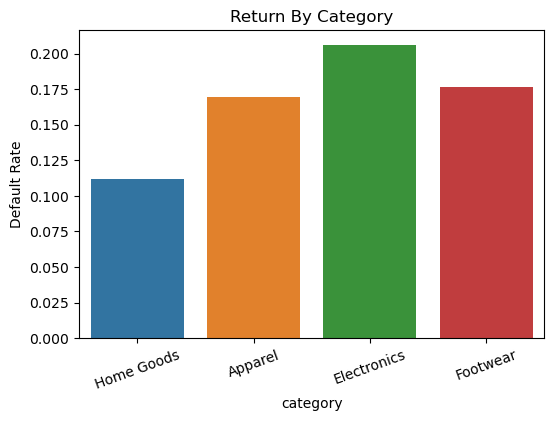

In [49]:
#Visualizing returns by category
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='category', y='is_returned', errorbar=None)
plt.title('Return By Category')
plt.ylabel('Default Rate')
plt.xticks(rotation=20)
plt.show()

In [50]:
# One Hot Encoding
df_model = pd.get_dummies(
    df,
    columns=[
        'category',
        'sub_category',
        'payment_method'
    ],
    drop_first=True
)
df_model.head()

,price,discount_pct,delivery_days,is_returned,avg_rating,order_month,order_dayofweek,is_weekend,category_Electronics,category_Footwear,category_Home Goods,sub_category_Air Fryers,sub_category_Bedsheets,sub_category_Blenders,sub_category_Bluetooth Speakers,sub_category_Boots,sub_category_Cameras,sub_category_Chargers,sub_category_Coffee Makers,sub_category_Cookware Sets,sub_category_Dresses,sub_category_Earbuds,sub_category_Formal Shoes,sub_category_Headphones,sub_category_Jackets,sub_category_Jeans,sub_category_Lamps,sub_category_Laptops,sub_category_Loafers,sub_category_Power Banks,sub_category_Running Shoes,sub_category_Sandals,sub_category_Smartphones,sub_category_Smartwatches,sub_category_Sneakers,sub_category_Storage Bins,sub_category_Sweaters,sub_category_T-Shirts,sub_category_Tablets,sub_category_Vacuum Cleaners,payment_method_UPI,payment_method_card,payment_method_netbanking,payment_method_wallet
0,9389.19,15,5,0,2.9,10,6,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,9608.99,0,4,0,3.9,8,1,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,3940.27,0,3,0,3.6,1,4,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,31126.63,10,4,0,3.0,11,6,1,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,2229.49,25,3,0,3.0,12,2,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [51]:
# Splitting features and target
X =df_model.drop(columns=['is_returned'])
y = df_model['is_returned']

# train_test_split with test_size=0.2, random_state=42, stratify=y
# stratifying to maintain even distribution of target in train/test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1200, 43) (300, 43)


In [52]:
#######################
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(
    "ROC-AUC Random Forest:",
    round(roc_auc_score(y_test, rf_proba), 3)
)
##############################
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_proba = gb_model.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC Gradient Boosting:",
    round(roc_auc_score(y_test, gb_proba), 3)
)

ROC-AUC Random Forest: 0.534
ROC-AUC Gradient Boosting: 0.581


In [53]:
# StandardScaler: To scale all numeric data to the same numeric range
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [54]:
# Creating a Logistic Regrassor model to classify
# Since target variable has an either/or value, henge choosing Logistic Regressor
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


In [55]:
# Generating predictions on test data
y_pred = model.predict(X_test_scaled)

# Generating probability on test data
y_proba = model.predict_proba(X_test_scaled)[:, 1]


In [56]:
best_result = None

for threshold in np.arange(0.01, 1.00, 0.01):
    y_pred_temp = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    recall = tp / (tp + fn)
    
    # Keep at least 90% recall
    if recall >= 0.90:
        
        if best_result is None or fp < best_result['fp']:
            best_result = {
                'threshold': threshold,
                'tp': tp,
                'fp': fp,
                'fn': fn,
                'tn': tn,
                'recall': recall
            }

best_result

{'threshold': 0.34, 'tp': 45, 'fp': 194, 'fn': 5, 'tn': 56, 'recall': 0.9}

** Choosing threshold to be 0.34 prioritizing Recall while minimising false positives 
as It is better to incorrectly flag some orders as potential returns
than to miss an order that actually will be returned. **

In [57]:
y_pred = model.predict(X_test_scaled)

# Generating probability on test data
y_proba = model.predict_proba(X_test_scaled)[:, 1]

y_pred = (y_proba >= 0.34).astype(int)

In [58]:
# Evaluating model performance metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1 Score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 3))

Accuracy : 0.337
Precision: 0.188
Recall   : 0.9
F1 Score : 0.311
ROC-AUC  : 0.601


## ROC-AUC Random Forest: 0.534
## ROC-AUC Gradient Boosting: 0.581
## ROC-AUC  : 0.601
## Based on ROC-AUC metrics, and the need for capturing True Positives the best over minimising False Positives, the choice of model is thus Logistic Regression

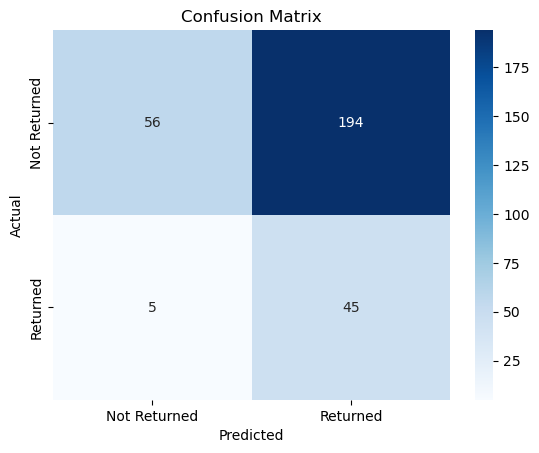

              precision    recall  f1-score   support

           0       0.92      0.22      0.36       250
           1       0.19      0.90      0.31        50

    accuracy                           0.34       300
   macro avg       0.55      0.56      0.34       300
weighted avg       0.80      0.34      0.35       300



In [59]:
# Visualizing the confusion matrix (TP/TN/FP/FN)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Returned', 'Returned'],
    yticklabels=['Not Returned', 'Returned']
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

In [60]:
# building the coefficient DataFrame to get feature importance
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df

,feature,coefficient
2,delivery_days,0.171009
1,discount_pct,0.155943
30,sub_category_Sandals,0.132669
16,sub_category_Chargers,0.126988
0,price,0.100210
19,sub_category_Dresses,0.099132
7,category_Electronics,0.090176
36,sub_category_T-Shirts,0.087803
17,sub_category_Coffee Makers,0.075550
13,sub_category_Bluetooth Speakers,0.071103


In [157]:
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']